Preprocessing AnnData ZARR

AnnData ZARR Package

In [3]:
!pip install anndata zarr numpy open3d


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: C:\Users\ryash\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [16]:
!pip install matplotlib scipy

     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ------------------------------------ - 51.2/52.8 kB 871.5 kB/s eta 0:00:01
     ------------------------------------ - 51.2/52.8 kB 871.5 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 340.8 kB/s eta 0:00:00
     ---------------------------------------- 0.0/119.8 kB ? eta -:--:--
     -------------------------------------- 119.8/119.8 kB 3.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/8.2 MB 30.4 MB/s eta 0:00:01
   ---------------- ----------------------- 3.3/8.2 MB 42.8 MB/s eta 0:00:01
   -------------------------- ------------- 5.4/8.2 MB 43.3 MB/s eta 0:00:01
   ------------------------------------- -- 7.7/8.2 MB 44.9 MB/s eta 0:00:01
   ---------------------------------------  8.2/8.2 MB 43.8 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 35.0 MB/s eta 0:00:00
   -


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: C:\Users\ryash\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


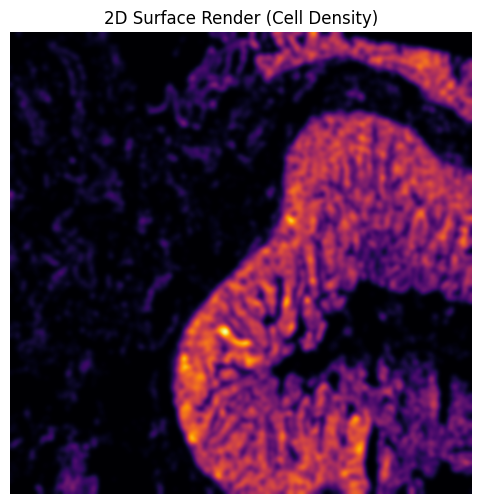

In [17]:
import anndata as ad
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Load data
adata = ad.read_zarr("reg001_expr-anndata.zarr")
coords = adata.obsm["xy"]

# Normalize (keeps things well-scaled)
coords = coords - coords.mean(axis=0)
coords = coords / coords.max()

# Create density grid
heatmap, xedges, yedges = np.histogram2d(
    coords[:, 0],
    coords[:, 1],
    bins=512   # higher = more detail
)

# Smooth it (this is what makes it a "surface")
surface = gaussian_filter(heatmap, sigma=3)

# Display
plt.figure(figsize=(6,6))
plt.imshow(surface.T, origin='lower', cmap='inferno')
plt.axis('off')
plt.title("2D Surface Render (Cell Density)")
plt.show()